In [70]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/liar-dataset/test.tsv
/kaggle/input/liar-dataset/README
/kaggle/input/liar-dataset/train.tsv
/kaggle/input/liar-dataset/valid.tsv


In [71]:

def read_dataframe(tsv_file: str) -> pd.DataFrame:
    
    df = pd.read_csv(tsv_file, delimiter='\t', dtype=object)
    
    df.fillna("", inplace=True)
    
    # labels the columns in the dataset using the data dictionary described in the README
    df.columns = [
        'id',                # Column 1: the ID of the statement ([ID].json).
        'label',             # Column 2: the label.
        'statement',         # Column 3: the statement.
        'subjects',          # Column 4: the subject(s).
        'speaker',           # Column 5: the speaker.
        'speaker_job_title', # Column 6: the speaker's job title.
        'state_info',        # Column 7: the state info.
        'party_affiliation', # Column 8: the party affiliation.
        
        # Column 9-13: the total credit history count, including the current statement.
        'count_1', # barely true counts.
        'count_2', # false counts.
        'count_3', # half true counts.
        'count_4', # mostly true counts.
        'count_5', # pants on fire counts.
        
        'context' # Column 14: the context (venue / location of the speech or statement).
    ]
    
    return df

#create a dataframe from the training data
df_train = read_dataframe('/kaggle/input/liar-dataset/train.tsv')

In [72]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10239 entries, 0 to 10238
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id                 10239 non-null  object
 1   label              10239 non-null  object
 2   statement          10239 non-null  object
 3   subjects           10239 non-null  object
 4   speaker            10239 non-null  object
 5   speaker_job_title  10239 non-null  object
 6   state_info         10239 non-null  object
 7   party_affiliation  10239 non-null  object
 8   count_1            10239 non-null  object
 9   count_2            10239 non-null  object
 10  count_3            10239 non-null  object
 11  count_4            10239 non-null  object
 12  count_5            10239 non-null  object
 13  context            10239 non-null  object
dtypes: object(14)
memory usage: 1.1+ MB


In [74]:
sns.set_palette("rocket_r")

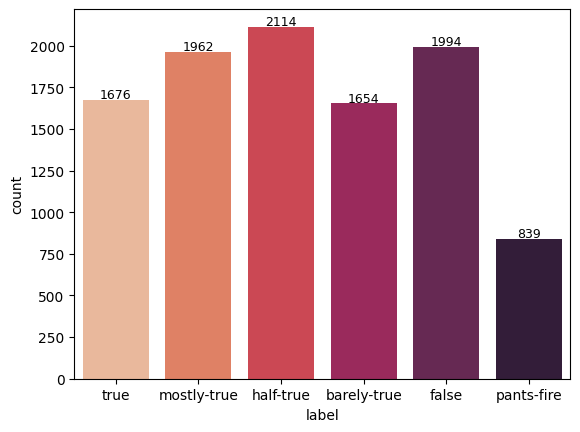

In [75]:
ax = sns.countplot(x='label', 
                   data=df_train, 
                 
                   order=['true', 'mostly-true', 'half-true', 'barely-true', 'false', 'pants-fire'],)


for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(p.get_x() + p.get_width()/2, height + 10, int(height), ha="center", fontsize=9)


plt.show()

**COMBINING THE TRUE AND FALSE COUNTS INTO A BI-LABEL COLUMN**

In [76]:
df_train['bi_label'] = df_train['label'].apply(
    lambda status: 'true' if status in ['true', 'mostly-true', 'half-true', 'barely-true'] 
                   else 'false' if status in ['false', 'pants-fire'] 
                   else None
)

In [77]:
df_train.head()

,id,label,statement,subjects,speaker,speaker_job_title,state_info,party_affiliation,count_1,count_2,count_3,count_4,count_5,context,bi_label
0,10540.json,half-true,When did the decline of coal start? It started...,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0,0,1,1,0,a floor speech.,true
1,324.json,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70,71,160,163,9,Denver,true
2,1123.json,false,Health care reform legislation is likely to ma...,health-care,blog-posting,,,none,7,19,3,5,44,a news release,false
3,9028.json,half-true,The economic turnaround started at the end of ...,"economy,jobs",charlie-crist,,Florida,democrat,15,9,20,19,2,an interview on CNN,true
4,12465.json,true,The Chicago Bears have had more starting quart...,education,robin-vos,Wisconsin Assembly speaker,Wisconsin,republican,0,3,2,5,1,a an online opinion-piece,true


In [78]:
sns.set_palette("pastel")

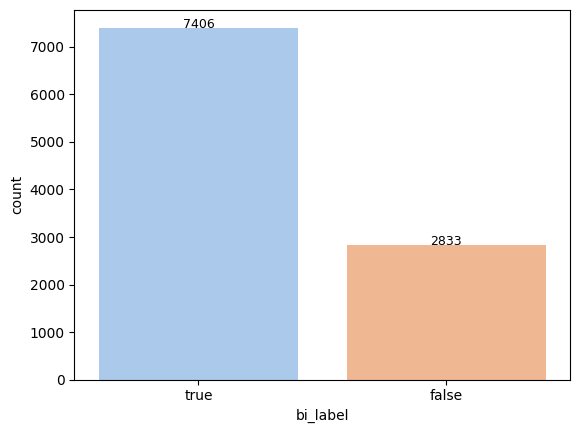

In [79]:
ax = sns.countplot(
    x='bi_label', 
    data=df_train, 
    order=['true', 'false'],
)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(p.get_x() + p.get_width() / 2., height + 1, int(height), ha="center", fontsize=9)


plt.show()

**TEST DATA**

In [84]:
#create a dataframe from the test data
df_test = read_dataframe('/kaggle/input/liar-dataset/test.tsv')

In [85]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1266 entries, 0 to 1265
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id                 1266 non-null   object
 1   label              1266 non-null   object
 2   statement          1266 non-null   object
 3   subjects           1266 non-null   object
 4   speaker            1266 non-null   object
 5   speaker_job_title  1266 non-null   object
 6   state_info         1266 non-null   object
 7   party_affiliation  1266 non-null   object
 8   count_1            1266 non-null   object
 9   count_2            1266 non-null   object
 10  count_3            1266 non-null   object
 11  count_4            1266 non-null   object
 12  count_5            1266 non-null   object
 13  context            1266 non-null   object
dtypes: object(14)
memory usage: 138.6+ KB


In [86]:
df_test['bi_label'] = df_test['label'].apply(
    lambda status: 'true' if status in ['true', 'mostly-true', 'half-true', 'barely-true'] 
                   else 'false' if status in ['false', 'pants-fire'] 
                   else None
)

In [87]:
df_test.head()

,id,label,statement,subjects,speaker,speaker_job_title,state_info,party_affiliation,count_1,count_2,count_3,count_4,count_5,context,bi_label
0,11685.json,false,Wisconsin is on pace to double the number of l...,jobs,katrina-shankland,State representative,Wisconsin,democrat,2,1,0,0,0,a news conference,false
1,11096.json,false,Says John McCain has done nothing to help the ...,"military,veterans,voting-record",donald-trump,President-Elect,New York,republican,63,114,51,37,61,comments on ABC's This Week.,false
2,5209.json,half-true,Suzanne Bonamici supports a plan that will cut...,"medicare,message-machine-2012,campaign-adverti...",rob-cornilles,consultant,Oregon,republican,1,1,3,1,1,a radio show,true
3,9524.json,pants-fire,When asked by a reporter whether hes at the ce...,"campaign-finance,legal-issues,campaign-adverti...",state-democratic-party-wisconsin,,Wisconsin,democrat,5,7,2,2,7,a web video,false
4,5962.json,true,Over the past five years the federal governmen...,"federal-budget,pensions,retirement",brendan-doherty,,Rhode Island,republican,1,2,1,1,0,a campaign website,true


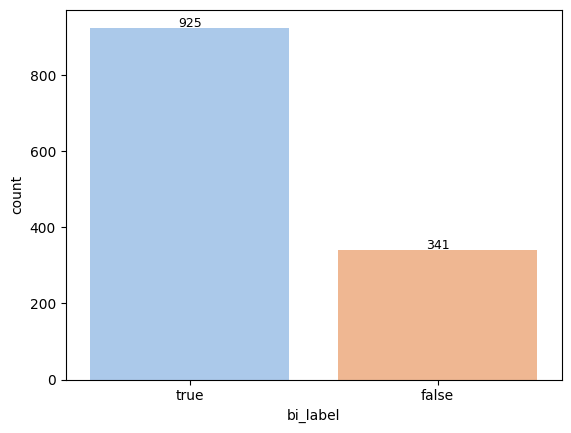

In [101]:
ax = sns.countplot(
    x='bi_label', 
    data=df_test,  
    order=['true', 'false'],
)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(p.get_x() + p.get_width() / 2., height + 1, int(height), ha="center", fontsize=9)

plt.show()

**VALIDATION SET**

In [92]:
df_valid = read_dataframe('/kaggle/input/liar-dataset/valid.tsv')

In [94]:
df_valid['bi_label'] = df_valid['label'].apply(
    lambda status: 'true' if status in ['true', 'mostly-true', 'half-true', 'barely-true'] 
                   else 'false' if status in ['false', 'pants-fire'] 
                   else None
)

In [95]:
df_valid.head()

,id,label,statement,subjects,speaker,speaker_job_title,state_info,party_affiliation,count_1,count_2,count_3,count_4,count_5,context,bi_label
0,238.json,pants-fire,"When Obama was sworn into office, he DID NOT u...","obama-birth-certificate,religion",chain-email,,,none,11,43,8,5,105,,false
1,7891.json,false,Says Having organizations parading as being so...,"campaign-finance,congress,taxes",earl-blumenauer,U.S. representative,Oregon,democrat,0,1,1,1,0,a U.S. Ways and Means hearing,false
2,8169.json,half-true,Says nearly half of Oregons children are poor.,poverty,jim-francesconi,Member of the State Board of Higher Education,Oregon,none,0,1,1,1,0,an opinion article,true
3,929.json,half-true,On attacks by Republicans that various program...,"economy,stimulus",barack-obama,President,Illinois,democrat,70,71,160,163,9,interview with CBS News,true
4,9416.json,false,Says when armed civilians stop mass shootings ...,guns,jim-rubens,Small business owner,New Hampshire,republican,1,1,0,1,0,"in an interview at gun shop in Hudson, N.H.",false


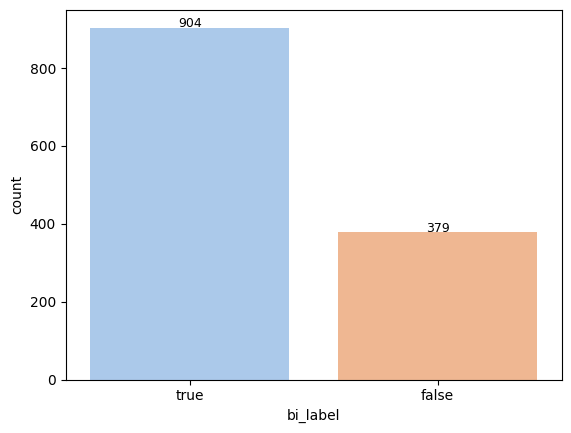

In [103]:
ax = sns.countplot(
    x='bi_label', 
    data=df_valid , 
    order=['true', 'false'],
)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(p.get_x() + p.get_width() / 2., height +1, int(height), ha="center", fontsize=9)


plt.show()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1283 entries, 0 to 1282
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id                 1283 non-null   object
 1   label              1283 non-null   object
 2   statement          1283 non-null   object
 3   subjects           1283 non-null   object
 4   speaker            1283 non-null   object
 5   speaker_job_title  1283 non-null   object
 6   state_info         1283 non-null   object
 7   party_affiliation  1283 non-null   object
 8   count_1            1283 non-null   object
 9   count_2            1283 non-null   object
 10  count_3            1283 non-null   object
 11  count_4            1283 non-null   object
 12  count_5            1283 non-null   object
 13  context            1283 non-null   object
 14  bi_label           1283 non-null   object
dtypes: object(15)
memory usage: 150.5+ KB
